# 3K - PCA do bloco de crescimento/acoplamento do Nino 3.4

**Pergunta especifica.** Entre as variaveis que descrevem o CRESCIMENTO e o ACOPLAMENTO dos eventos `forte_p90` e `super_p95`, qual e o conjunto minimo indispensavel de dimensoes fisicas independentes?

**Objetivo.** Reduzir o bloco de crescimento por PCA e identificar 1 representante por componente, expondo a redundancia entre variaveis de recarga.

**Justificativa.** Muitas variaveis medem o mesmo estado fisico. O PCA evita contar a mesma evidencia varias vezes no parecer. Eventos abaixo do P90 nao entram nesta analise.

**Metodologia.** Amostras = semanas em fase de crescimento (onset->pico) apenas dos eventos P90/P95. Variaveis = SSTA, D20, OHC, SSH, tilt, WWV, tau_x, DHW 12w. Padronizacao z-score; PCA; scree, loadings e biplot; representante de maior |loading| por PC ate 90% da variancia.

**Saidas.** `phase3K_pca_variancia.csv`, `phase3K_pca_loadings.csv`, `phase3K_conjunto_indispensavel.csv`, `phase3K_scree.png`, `phase3K_biplot.png`.


In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import fase3_utils as u

w=pd.read_csv(u.FEAT/'phase3_indices_semanais.csv',parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
ev=u.events_p90_p95()
GROW=['nino34_ssta','d20_m','ohc_0_300','ohc_0_700','ssh_m','tilt_m','wwv','tau_x_proxy_nino34_pa','dhw_12w']
mask=pd.Series(False,index=w.index)
for _,e in ev.iterrows(): mask.loc[e.event_start:e.peak_time]=True
Xdf=w.loc[mask & (w.index>='1993-01-01'), GROW].dropna()
print('amostras de crescimento P90/P95 (1993+):',Xdf.shape,'| eventos=',len(ev))
X=StandardScaler().fit_transform(Xdf.values)
pca=PCA().fit(X); evr=pca.explained_variance_ratio_
var=pd.DataFrame({'componente':[f'PC{i+1}' for i in range(len(evr))],'var_explicada':evr.round(3),'var_acumulada':evr.cumsum().round(3)})
u.save_table(var,'phase3K_pca_variancia.csv',index=False)
load=pd.DataFrame(pca.components_[:4].T,index=Xdf.columns,columns=[f'PC{i+1}' for i in range(4)]).round(3)
u.save_table(load,'phase3K_pca_loadings.csv')
n90=int(np.argmax(evr.cumsum()>=0.90)+1)
print(f'{n90} PCs explicam >=90% (PC1={evr[0]:.2f}, PC2={evr[1]:.2f}, PC3={evr[2]:.2f})')
load


amostras de crescimento P90/P95 (1993+): (179, 9) | eventos= 10
[tabela] data\processed\parquet\statistics\phase3K_pca_variancia.csv
[tabela] data\processed\parquet\statistics\phase3K_pca_loadings.csv
4 PCs explicam >=90% (PC1=0.68, PC2=0.12, PC3=0.08)


,PC1,PC2,PC3,PC4
nino34_ssta,0.356,-0.187,0.195,-0.424
d20_m,0.322,0.371,-0.390,0.375
ohc_0_300,0.393,0.102,-0.207,0.110
ohc_0_700,0.385,0.115,-0.261,0.024
ssh_m,0.383,0.037,-0.098,-0.104
tilt_m,0.329,-0.366,-0.072,-0.004
wwv,0.166,0.704,0.620,-0.034
tau_x_proxy_nino34_pa,0.245,-0.387,0.509,0.695
dhw_12w,0.351,-0.151,0.204,-0.415


In [2]:
# conjunto indispensavel: representante distinto por PC ate 90%
picked=[]; rows=[]
sig={'PC1':'recarga/subsuperficie (amplitude)','PC2':'acoplamento vento-superficie','PC3':'forcante independente'}
for pc in [f'PC{i+1}' for i in range(n90)]:
    s=load[pc].abs().sort_values(ascending=False)
    for v in s.index:
        if v not in picked: picked.append(v); rows.append({'PC':pc,'representante':v,'|loading|':round(s[v],3),'interpretacao':sig.get(pc,'-')}); break
ind=pd.DataFrame(rows); u.save_table(ind,'phase3K_conjunto_indispensavel.csv',index=False)
ind

[tabela] data\processed\parquet\statistics\phase3K_conjunto_indispensavel.csv


,PC,representante,|loading|,interpretacao
0,PC1,ohc_0_300,0.393,recarga/subsuperficie (amplitude)
1,PC2,wwv,0.704,acoplamento vento-superficie
2,PC3,tau_x_proxy_nino34_pa,0.509,forcante independente
3,PC4,nino34_ssta,0.424,-


[figura] data\processed\figures\fase3\phase3K_scree.png

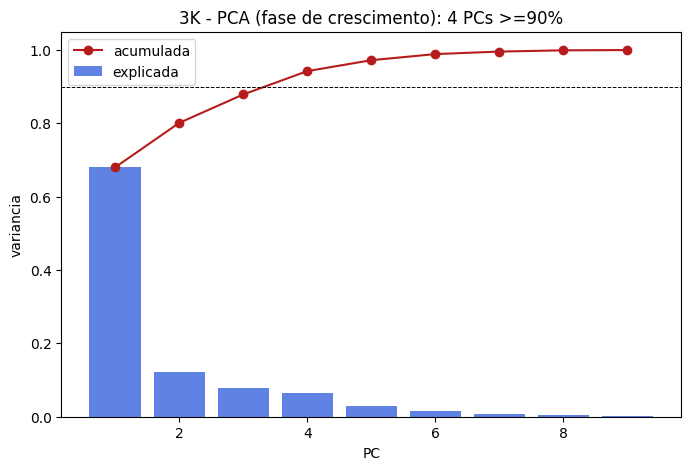

In [3]:
# scree
fig,ax=plt.subplots(figsize=(8,5)); x=range(1,len(evr)+1)
ax.bar(x,evr,color='#1d4ed8',alpha=.7,label='explicada'); ax.plot(x,evr.cumsum(),'o-',color='#b71c1c',label='acumulada')
ax.axhline(.9,ls='--',color='k',lw=.7); ax.set_xlabel('PC'); ax.set_ylabel('variancia'); ax.legend()
ax.set_title(f'3K - PCA (fase de crescimento): {n90} PCs >=90%'); u.save_fig(fig,'phase3K_scree.png'); plt.show()

[figura] data\processed\figures\fase3\phase3K_biplot.png


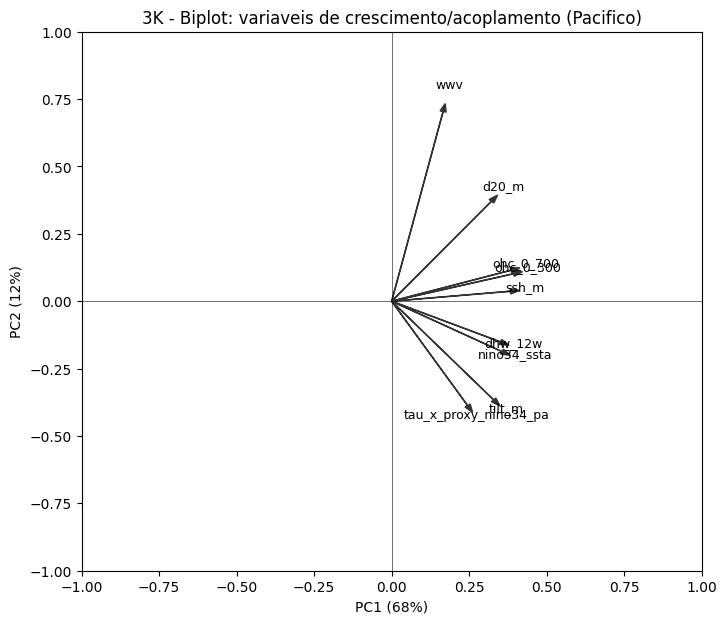

In [4]:
# biplot PC1xPC2
fig,ax=plt.subplots(figsize=(8,7))
for v in Xdf.columns:
    ax.arrow(0,0,load.loc[v,'PC1'],load.loc[v,'PC2'],head_width=.02,color='#333')
    ax.text(load.loc[v,'PC1']*1.12,load.loc[v,'PC2']*1.12,v,fontsize=9,ha='center')
ax.axhline(0,color='k',lw=.4); ax.axvline(0,color='k',lw=.4); ax.set_xlim(-1,1); ax.set_ylim(-1,1)
ax.set_xlabel(f'PC1 ({evr[0]*100:.0f}%)'); ax.set_ylabel(f'PC2 ({evr[1]*100:.0f}%)')
ax.set_title('3K - Biplot: variaveis de crescimento/acoplamento (Pacifico)'); u.save_fig(fig,'phase3K_biplot.png'); plt.show()

In [5]:
# Explicacao das variaveis por tras de cada PC (nao basta a % - importa QUEM carrega)
load_abs=load.abs()
print('Variancia:', ' '.join(f'PC{i+1}={evr[i]*100:.0f}%' for i in range(min(4,len(evr)))),
      f'| {n90} PCs = {evr[:n90].sum()*100:.0f}%')
print()
for pc in [f'PC{i+1}' for i in range(n90)]:
    top=load[pc].abs().sort_values(ascending=False).head(3)
    membros=', '.join(f'{v}({load.loc[v,pc]:+.2f})' for v in top.index)
    print(f'{pc} ({evr[int(pc[2:])-1]*100:.0f}% da variancia) dominado por: {membros}')
# tabela explicativa
rows=[]
for i,pc in enumerate([f'PC{k+1}' for k in range(n90)]):
    top=load[pc].abs().sort_values(ascending=False).head(3)
    rows.append({'PC':pc,'var_explicada_%':round(evr[i]*100,1),
                 'variaveis_dominantes':', '.join(top.index),
                 'loadings':', '.join(f'{load.loc[v,pc]:+.2f}' for v in top.index)})
expl=pd.DataFrame(rows); u.save_table(expl,'phase3K_pcs_explicados.csv',index=False); expl

Variancia: PC1=68% PC2=12% PC3=8% PC4=6% | 4 PCs = 94%

PC1 (68% da variancia) dominado por: ohc_0_300(+0.39), ohc_0_700(+0.39), ssh_m(+0.38)
PC2 (12% da variancia) dominado por: wwv(+0.70), tau_x_proxy_nino34_pa(-0.39), d20_m(+0.37)
PC3 (8% da variancia) dominado por: wwv(+0.62), tau_x_proxy_nino34_pa(+0.51), d20_m(-0.39)
PC4 (6% da variancia) dominado por: tau_x_proxy_nino34_pa(+0.69), nino34_ssta(-0.42), dhw_12w(-0.41)
[tabela] data\processed\parquet\statistics\phase3K_pcs_explicados.csv


,PC,var_explicada_%,variaveis_dominantes,loadings
0,PC1,68.0,"ohc_0_300, ohc_0_700, ssh_m","+0.39, +0.39, +0.38"
1,PC2,12.1,"wwv, tau_x_proxy_nino34_pa, d20_m","+0.70, -0.39, +0.37"
2,PC3,7.8,"wwv, tau_x_proxy_nino34_pa, d20_m","+0.62, +0.51, -0.39"
3,PC4,6.4,"tau_x_proxy_nino34_pa, nino34_ssta, dhw_12w","+0.69, -0.42, -0.41"


**Leitura do 3K.** Se PC1 concentra a maior parte da variancia e agrega D20/OHC/SSH/tilt, isso confirma que essas variaveis sao **uma unica dimensao de recarga** - basta um representante. PC2 tende a isolar o vento (tau_x) e o DHW como eixo de acoplamento/calor. O conjunto indispensavel (tabela) e o que deve entrar num modelo da Fase 5 sem redundancia; o restante e colinear e nao acrescenta grau de liberdade fisico. Escopo estritamente Pacifico.